# Black-Scholes model for option pricing

## Parameters
- Current stock price
- Amount of time until expiration (will do an array of different times)
- Strike price (same as amount of time, will do an array)
- Volatility (either array of volatilities, or later implement a function to predict it from historical data)
- Risk-free interest rate

In [3]:
# Import libraries
import pandas
import numpy
import scipy.stats
import matplotlib

## Black Scholes notes

1) Propose a series of possible prices at expiration
2) Calculate the probability of each price at expiration using the lognormal distribution
3) Calculate the payoff of the option at each price at expiration (calculate forward price at expiration, then calculate payoff)


In [4]:
# Black Scholes model for option pricing
def black_scholes(current_price, strike_price, time_to_expiration, volatility, risk_free_rate, dividend = 0):
    ## Step 1: Propose a series of possible prices at expiration
    interval = min(current_price * 0.01, 1)
    
    forward_price = current_price * numpy.exp(risk_free_rate * time_to_expiration) - dividend * time_to_expiration
    # print(f"Forward price: {forward_price:.2f}")
    possible_prices = numpy.arange(0, forward_price * 2, interval)

    ## Step 2: Calculate the probability of each price at expiration (lognormal)
    ## volatility is expected probability of price change within 1 standard deviation, yearly

    std_dev = volatility * numpy.sqrt(time_to_expiration)
    scale = numpy.exp(numpy.log(forward_price) - (std_dev**2) / 2)
    # lognormal distribution
    probabilities = scipy.stats.lognorm.pdf(possible_prices, s=std_dev, scale=scale)
    # print(f"Sum of probabilities: {numpy.sum(probabilities):.4f}")

    ## Step 3: Calculate the payoff of the option at each price at expiration

    # payoffs: call option: max(possible_price - strike_price, 0)
    call_payoffs = numpy.maximum(possible_prices - strike_price, 0)
    # expected payoff: sum of payoffs * probabilities
    call_expected_payoff = numpy.sum(call_payoffs * probabilities)
    # discount expected payoff to present value
    call_price = call_expected_payoff * numpy.exp(-risk_free_rate * time_to_expiration)

    put_payoffs = numpy.maximum(strike_price - possible_prices, 0)
    put_expected_payoff = numpy.sum(put_payoffs * probabilities)
    put_price = put_expected_payoff * numpy.exp(-risk_free_rate * time_to_expiration)

    return call_price, put_price


In [5]:
# Try the function with some parameters
current_price = 100
strike_price = [x for x in range(80, 125, 5)]
time_to_expiration = 30 / 252
volatility = 0.2
risk_free_rate = 0.01

for strike in strike_price:
    call_price, put_price = black_scholes(current_price, strike, time_to_expiration, volatility, risk_free_rate)
    print(f"Strike price: {strike}, Call price: {call_price:.2f}, Put price: {put_price:.2f}")

Strike price: 80, Call price: 20.10, Put price: 0.00
Strike price: 85, Call price: 15.12, Put price: 0.02
Strike price: 90, Call price: 10.28, Put price: 0.17
Strike price: 95, Call price: 5.97, Put price: 0.86
Strike price: 100, Call price: 2.81, Put price: 2.69
Strike price: 105, Call price: 1.02, Put price: 5.90
Strike price: 110, Call price: 0.29, Put price: 10.15
Strike price: 115, Call price: 0.06, Put price: 14.92
Strike price: 120, Call price: 0.01, Put price: 19.87


In [6]:
# Calculate number of trading days between two dates
def trading_days(start_date, end_date):
    # Create a date range
    dates = pandas.date_range(start=start_date, end=end_date, freq='B')  # 'B' frequency means business days
    return len(dates)

In [7]:
# Testing with actual market data
# Read data first
stock_price_data = pandas.read_csv("../data/raw/SPY_history.csv", parse_dates=["date"])
today_price = stock_price_data["close"].iloc[-1]
today_date = stock_price_data["date"].iloc[-1]
dividend = 0
print(f"Today's date: {today_date.date()}, Price: {today_price:.2f}")

# Read option data (just the one file we have)
option_data = pandas.read_csv("../data/raw/SPY_options_2026-05-11.csv")

# Get expiry date from the data
expiry_date = option_data["expiry"].iloc[0]
time_to_expiration = trading_days(str(today_date.date()), expiry_date) / 252
print(f"\nExpiration date: {expiry_date}, Time to expiration: {time_to_expiration:.4f} years")

# Separate calls and puts
calls = option_data[option_data["option_type"] == "call"].copy()
puts = option_data[option_data["option_type"] == "put"].copy()

print(f"Found {len(calls)} calls, {len(puts)} puts")

# Compare for ATM options (within $15 of current price)
atm_calls = calls[abs(calls["strike"] - today_price) <= 15]
atm_puts = puts[abs(puts["strike"] - today_price) <= 15]

predicted_vol = 0.115
risk_free_rate = 0.045

print("\nATM Calls:")
for _, row in atm_calls.iterrows():
    strike = row["strike"]
    market_price = row["mid"]
    model_call, _ = black_scholes(today_price, strike, time_to_expiration, predicted_vol, risk_free_rate, dividend)
    diff = market_price - model_call
    print(f"Strike {strike}: Model={model_call:.2f}, Market={market_price:.2f}, Diff={diff:.2f}")

print("\nATM Puts:")
for _, row in atm_puts.iterrows():
    strike = row["strike"]
    market_price = row["mid"]
    _, model_put = black_scholes(today_price, strike, time_to_expiration, predicted_vol, risk_free_rate, dividend)
    diff = market_price - model_put
    print(f"Strike {strike}: Model={model_put:.2f}, Market={market_price:.2f}, Diff={diff:.2f}")

# Test Call-Put parity for all strikes
# Call - Put = Stock Price - Strike Price * exp(-r * T)
print("\nCall-Put Parity Check:")
for strike in sorted(set(calls["strike"]).intersection(set(puts["strike"]))):
    # Check for prices from the data
    call_row = calls[calls["strike"] == strike].iloc[0]
    put_row = puts[puts["strike"] == strike].iloc[0]
    call_price = call_row["mid"]
    put_price = put_row["mid"]
    parity_diff = call_price - put_price - (today_price - strike * numpy.exp(-risk_free_rate * time_to_expiration)) + dividend * time_to_expiration
    print(f"Strike {strike}: Call={call_price:.2f}, Put={put_price:.2f}, Parity Diff={parity_diff:.2f}")
    # Check for generated prices from the model
    model_call, model_put = black_scholes(today_price, strike, time_to_expiration, predicted_vol, risk_free_rate, dividend)
    model_parity_diff = model_call - model_put - (today_price - strike * numpy.exp(-risk_free_rate * time_to_expiration)) + dividend * time_to_expiration
    print(f"Model Call={model_call:.2f}, Model Put={model_put:.2f}, Model Parity Diff={model_parity_diff:.2f}")




Today's date: 2026-05-08, Price: 737.63

Expiration date: 2026-05-11, Time to expiration: 0.0079 years
Found 99 calls, 113 puts

ATM Calls:
Strike 723.0: Model=14.95, Market=14.61, Diff=-0.35
Strike 724.0: Model=13.98, Market=13.58, Diff=-0.40
Strike 725.0: Model=13.02, Market=12.64, Diff=-0.38
Strike 726.0: Model=12.07, Market=11.70, Diff=-0.37
Strike 727.0: Model=11.13, Market=10.80, Diff=-0.33
Strike 728.0: Model=10.22, Market=9.93, Diff=-0.29
Strike 729.0: Model=9.32, Market=8.93, Diff=-0.40
Strike 730.0: Model=8.46, Market=8.09, Diff=-0.37
Strike 731.0: Model=7.62, Market=7.21, Diff=-0.42
Strike 732.0: Model=6.82, Market=6.31, Diff=-0.51
Strike 733.0: Model=6.06, Market=5.53, Diff=-0.53
Strike 734.0: Model=5.34, Market=4.72, Diff=-0.62
Strike 735.0: Model=4.67, Market=3.96, Diff=-0.71
Strike 736.0: Model=4.05, Market=3.27, Diff=-0.78
Strike 737.0: Model=3.48, Market=2.65, Diff=-0.83
Strike 738.0: Model=2.96, Market=2.08, Diff=-0.87
Strike 739.0: Model=2.49, Market=1.60, Diff=-0.90

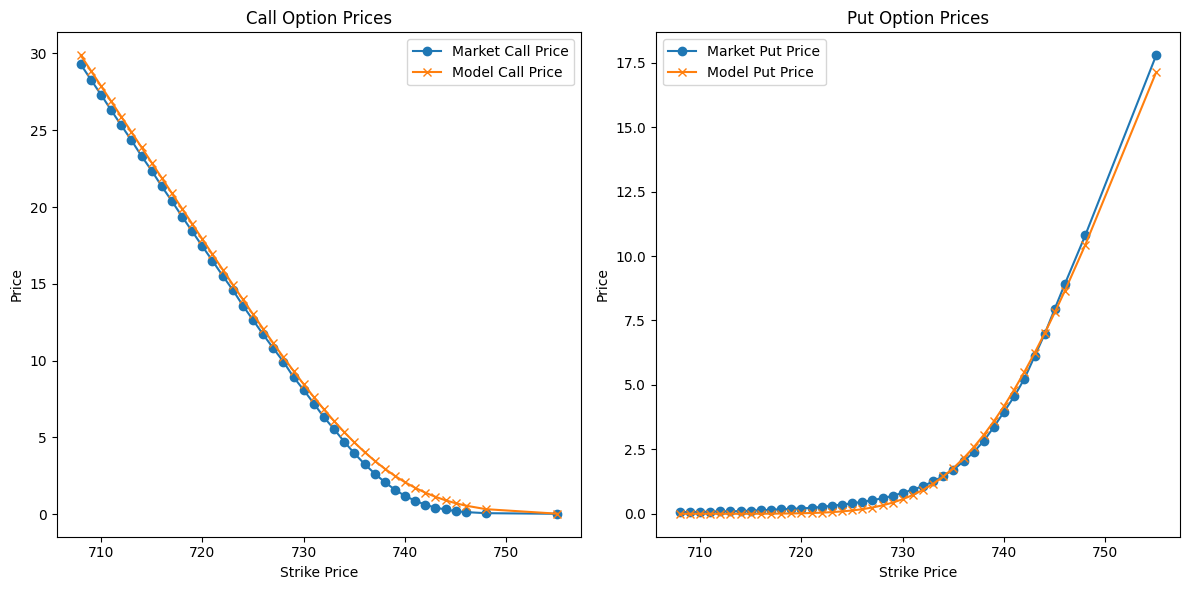

In [8]:
# Draw some plots to visualize the results
import matplotlib.pyplot as plt

strikes = sorted(set(calls["strike"]).intersection(set(puts["strike"])))
strikes = [strike for strike in strikes if abs(strike - today_price) <= 30]  # Focus on strikes within $30 of current price
market_call_prices = [calls[calls["strike"] == strike]["mid"].iloc[0] for strike in strikes]
market_put_prices = [puts[puts["strike"] == strike]["mid"].iloc[0] for strike in strikes]
model_call_prices = []
model_put_prices = []
for strike in strikes:
    model_call, model_put = black_scholes(today_price, strike, time_to_expiration, predicted_vol, risk_free_rate, dividend)
    model_call_prices.append(model_call)
    model_put_prices.append(model_put)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(strikes, market_call_prices, label="Market Call Price", marker='o')
plt.plot(strikes, model_call_prices, label="Model Call Price", marker='x')
plt.title("Call Option Prices")
plt.xlabel("Strike Price")
plt.ylabel("Price")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(strikes, market_put_prices, label="Market Put Price", marker='o')
plt.plot(strikes, model_put_prices, label="Model Put Price", marker='x')
plt.title("Put Option Prices")
plt.xlabel("Strike Price")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

Risk-free rate: 4.50%, Predicted Volatility: 11.50%

Strike | Market Call | Model Call | Implied Vol (Call) | Market Put | Model Put | Implied Vol (Put)
------------------------------------------------------------------------------------------
 708.0 |       29.29 |      29.88 |            0.0100 |       0.07 |      0.00 |           0.2105
 709.0 |       28.30 |      28.88 |            0.0100 |       0.07 |      0.00 |           0.2084
 710.0 |       27.32 |      27.88 |            0.0100 |       0.07 |      0.00 |           0.2021
 711.0 |       26.31 |      26.88 |            0.0100 |       0.08 |      0.00 |           0.1993
 712.0 |       25.32 |      25.88 |            0.0100 |       0.10 |      0.00 |           0.1961
 713.0 |       24.35 |      24.89 |            0.0100 |       0.10 |      0.00 |           0.1896
 714.0 |       23.32 |      23.89 |            0.0100 |       0.10 |      0.00 |           0.1859
 715.0 |       22.37 |      22.89 |            0.0100 |       0.12 |  

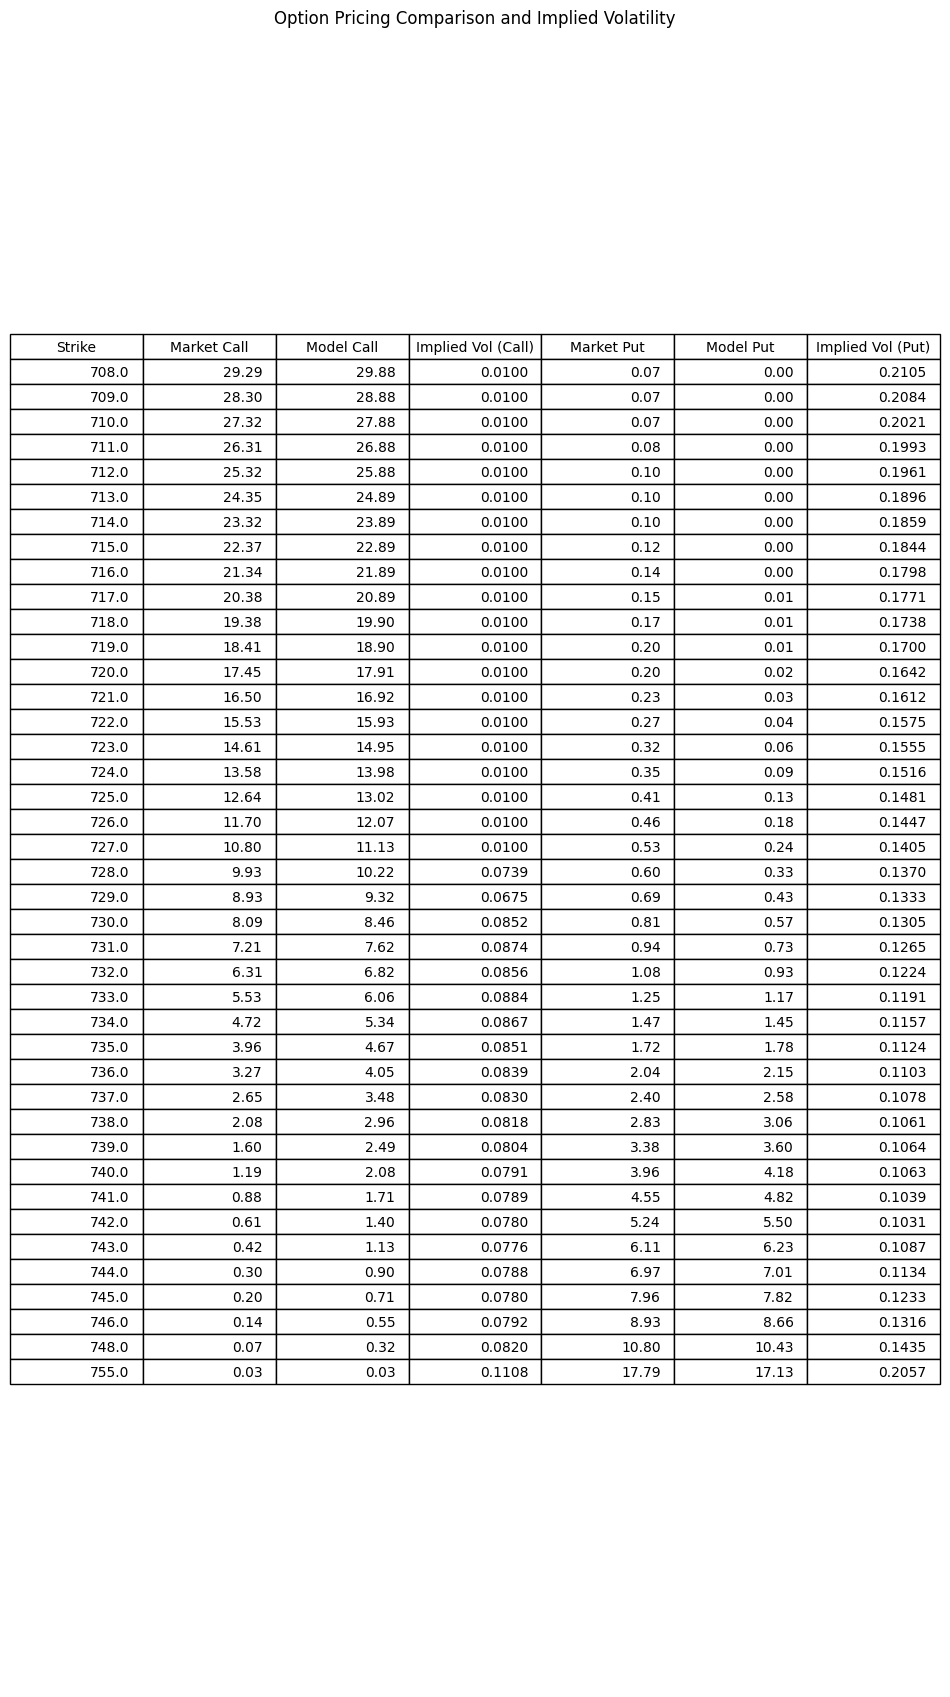

In [10]:
# Calculate implied volatility for each option from the market price
def implied_volatility(option_type, market_price, current_price, strike_price, time_to_exp):
    l = 0.01
    r = 1.0
    eps = 1e-5
    # binary search
    while r - l > eps:
        mid = (l + r) / 2
        model_call, model_put = black_scholes(current_price, strike_price, time_to_exp, mid, risk_free_rate, dividend)
        model_price = model_call if option_type == "call" else model_put
        if model_price > market_price:
            r = mid
        else:
            l = mid
    return (l + r) / 2

def draw_table():
    print("Risk-free rate: {:.2%}, Predicted Volatility: {:.2%}".format(risk_free_rate, predicted_vol))
    print("\nStrike | Market Call | Model Call | Implied Vol (Call) | Market Put | Model Put | Implied Vol (Put)")
    print("-" * 90)
    for strike in strikes:
        market_call_price = calls[calls["strike"] == strike]["mid"].iloc[0]
        market_put_price = puts[puts["strike"] == strike]["mid"].iloc[0]
        model_call_price, model_put_price = black_scholes(today_price, strike, time_to_expiration, predicted_vol, risk_free_rate, dividend)
        iv_call = implied_volatility("call", market_call_price, today_price, strike, time_to_expiration)
        iv_put = implied_volatility("put", market_put_price, today_price, strike, time_to_expiration)
        print(f"{strike:6} | {market_call_price:11.2f} | {model_call_price:10.2f} | {iv_call:17.4f} | {market_put_price:10.2f} | {model_put_price:9.2f} | {iv_put:16.4f}")
    
    # print picture of the table
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(12, len(strikes) * 0.5 + 1))
    ax.axis('tight')
    ax.axis('off')
    table_data = []
    for strike in strikes:
        market_call_price = calls[calls["strike"] == strike]["mid"].iloc[0]
        market_put_price = puts[puts["strike"] == strike]["mid"].iloc[0]
        model_call_price, model_put_price = black_scholes(today_price, strike, time_to_expiration, predicted_vol, risk_free_rate, dividend)
        iv_call = implied_volatility("call", market_call_price, today_price, strike, time_to_expiration)
        iv_put = implied_volatility("put", market_put_price, today_price, strike, time_to_expiration)
        table_data.append([strike, f"{market_call_price:.2f}", f"{model_call_price:.2f}", f"{iv_call:.4f}", f"{market_put_price:.2f}", f"{model_put_price:.2f}", f"{iv_put:.4f}"])
    column_labels = ["Strike", "Market Call", "Model Call", "Implied Vol (Call)", "Market Put", "Model Put", "Implied Vol (Put)"]
    table = ax.table(cellText=table_data, colLabels=column_labels, loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    plt.title("Option Pricing Comparison and Implied Volatility")
    plt.show()

draw_table()



In [14]:
# Calculate the Greeks for each option
def option_greeks(option_type, current_price, strike_price, time_to_expiration, volatility, risk_free_rate, dividend = 0):
    call_price, put_price = black_scholes(current_price, strike_price, time_to_expiration, volatility, risk_free_rate, dividend)
    call_price_2, put_price_2 = black_scholes(current_price + 0.1, strike_price, time_to_expiration, volatility, risk_free_rate, dividend)
    # Delta = dPrice/dS
    delta_call = (call_price_2 - call_price) / 0.1
    delta_put = (put_price_2 - put_price) / 0.1
    # Check if sum of delta is close to 1
    sum_delta = delta_call + abs(delta_put)
    print(f"Delta Call: {delta_call:.4f}, Delta Put: {delta_put:.4f}, Sum of Deltas: {sum_delta:.4f}")
    # Gamma = dDelta/dS
    gamma_call = ((call_price_2 - call_price) / 0.1 - delta_call) / 0.1
    gamma_put = ((put_price_2 - put_price) / 0.1 - delta_put) / 0.1
    # Theta = dPrice/dT (time decay)
    call_price_3, put_price_3 = black_scholes(current_price, strike_price, time_to_expiration - 1/252, volatility, risk_free_rate, dividend)
    theta_call = (call_price_3 - call_price) / (1/252)
    theta_put = (put_price_3 - put_price) / (1/252)
    # Vega = dPrice/dVolatility
    call_price_4, put_price_4 = black_scholes(current_price, strike_price, time_to_expiration, volatility + 0.01, risk_free_rate, dividend)
    vega_call = (call_price_4 - call_price) / 0.01
    vega_put = (put_price_4 - put_price) / 0.01

    if option_type == "call":
        return delta_call, gamma_call, theta_call, vega_call
    else:
        return delta_put, gamma_put, theta_put, vega_put

Risk-free rate: 4.50%, Predicted Volatility: 11.50%

Strike | Option Type | Delta | Gamma | Theta | Vega
------------------------------------------------------------
Delta Call: 1.0000, Delta Put: -0.0000, Sum of Deltas: 1.0000
 708.0 | call        | 1.0000 | 0.0000 | -31.8625 | 0.0149
Delta Call: 1.0000, Delta Put: -0.0000, Sum of Deltas: 1.0000
 708.0 | put         | -0.0000 | 0.0000 | -0.0110 | 0.0149
Delta Call: 1.0000, Delta Put: -0.0000, Sum of Deltas: 1.0000
 709.0 | call        | 1.0000 | 0.0000 | -31.9167 | 0.0245
Delta Call: 1.0000, Delta Put: -0.0000, Sum of Deltas: 1.0000
 709.0 | put         | -0.0000 | 0.0000 | -0.0202 | 0.0245
Delta Call: 0.9999, Delta Put: -0.0001, Sum of Deltas: 1.0000
 710.0 | call        | 0.9999 | 0.0000 | -31.9779 | 0.0396
Delta Call: 0.9999, Delta Put: -0.0001, Sum of Deltas: 1.0000
 710.0 | put         | -0.0001 | 0.0000 | -0.0365 | 0.0396
Delta Call: 0.9999, Delta Put: -0.0001, Sum of Deltas: 1.0000
 711.0 | call        | 0.9999 | 0.0000 | -32.0

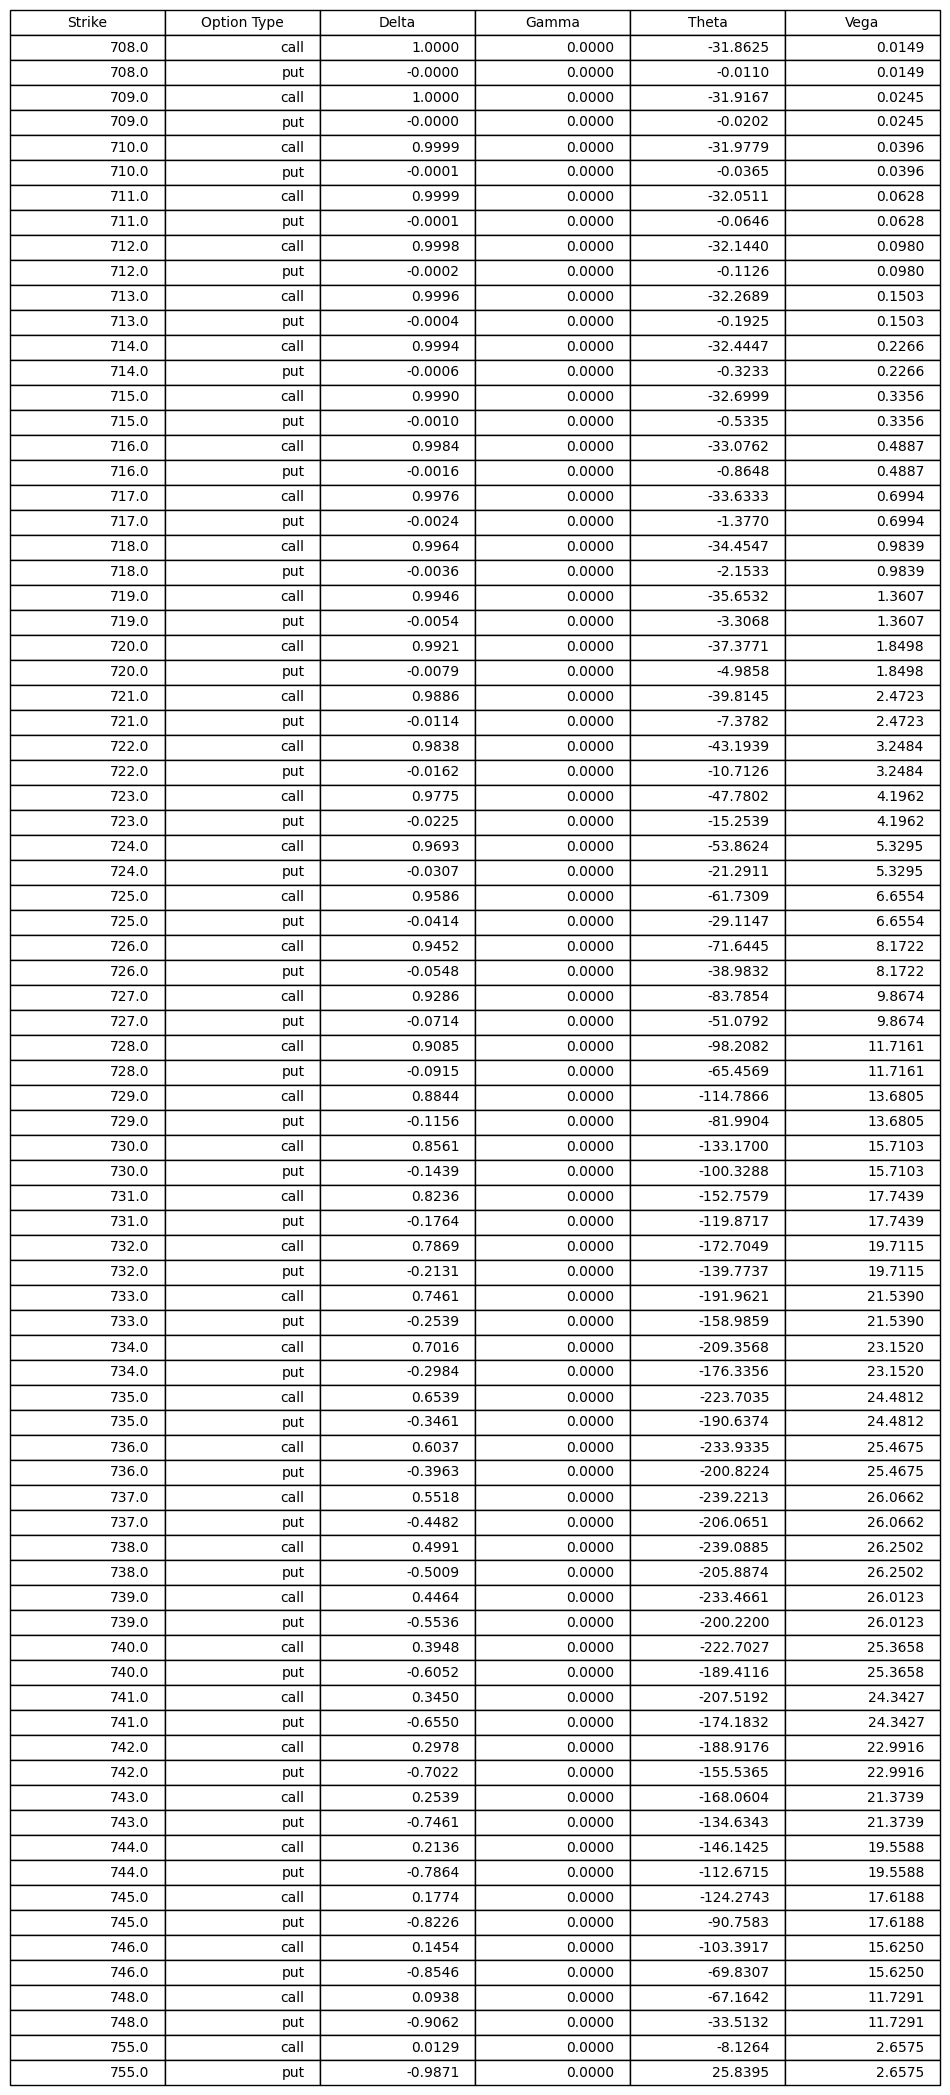

In [15]:
# Make table of Greeks for options
def draw_greeks_table():
    print("Risk-free rate: {:.2%}, Predicted Volatility: {:.2%}".format(risk_free_rate, predicted_vol))
    print("\nStrike | Option Type | Delta | Gamma | Theta | Vega")
    print("-" * 60)
    for strike in strikes:
        for option_type in ["call", "put"]:
            delta, gamma, theta, vega = option_greeks(option_type, today_price, strike, time_to_expiration, predicted_vol, risk_free_rate, dividend)
            print(f"{strike:6} | {option_type:11} | {delta:5.4f} | {gamma:5.4f} | {theta:5.4f} | {vega:5.4f}")
    
    # print picture of the table
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(12, len(strikes) * 0.5 + 1))
    ax.axis('tight')
    ax.axis('off')
    table_data = []
    for strike in strikes:
        for option_type in ["call", "put"]:
            delta, gamma, theta, vega = option_greeks(option_type, today_price, strike, time_to_expiration, predicted_vol, risk_free_rate, dividend)
            table_data.append([strike, option_type, f"{delta:.4f}", f"{gamma:.4f}", f"{theta:.4f}", f"{vega:.4f}"])
    column_labels = ["Strike", "Option Type", "Delta", "Gamma", "Theta", "Vega"]
    table = ax.table(cellText=table_data, colLabels=column_labels, loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    plt.show()

draw_greeks_table()